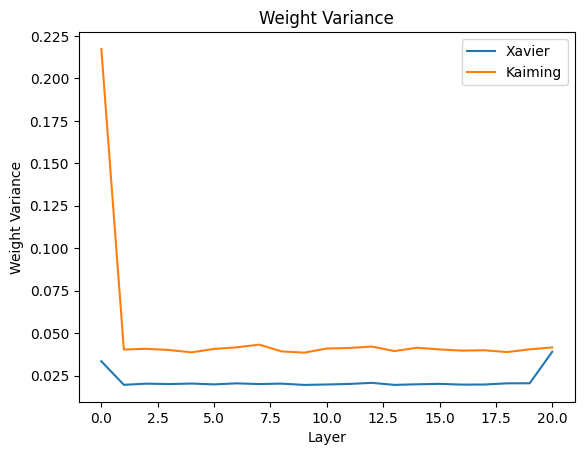

Xavier variances:
[0.033429041504859924, 0.019564388319849968, 0.020246952772140503, 0.020020846277475357, 0.020304931327700615, 0.019816676154732704, 0.02042626217007637, 0.020020652562379837, 0.02026025950908661, 0.019504424184560776, 0.01975179836153984, 0.020086057484149933, 0.02072114869952202, 0.01952817291021347, 0.019869057461619377, 0.020132169127464294, 0.019686011597514153, 0.019740570336580276, 0.02044806070625782, 0.020472535863518715, 0.03902483731508255]

Kaiming variances:
[0.2173476219177246, 0.04034319147467613, 0.040759745985269547, 0.04007318988442421, 0.03867281600832939, 0.04069269821047783, 0.04164937138557434, 0.043232351541519165, 0.03924022614955902, 0.03849765658378601, 0.04092717170715332, 0.041257236152887344, 0.04210002347826958, 0.039433982223272324, 0.04139801487326622, 0.04041927307844162, 0.03969706594944, 0.039903245866298676, 0.03885573148727417, 0.04045672342181206, 0.04156837612390518]


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

layers = [10] + [50] * 20 + [3]

def xavier_init(shape):
    fan_in, fan_out = shape
    limit = np.sqrt(6 / (fan_in + fan_out))
    return torch.empty(shape).uniform_(-limit, limit)

def kaiming_init(shape):
    fan_in, _ = shape
    return torch.randn(shape) * np.sqrt(2 / fan_in)

def check_weights(initializer):
    means = []
    variances = []

    for i in range(len(layers)-1):
        W = initializer((layers[i], layers[i+1]))
        means.append(W.mean().item())
        variances.append(W.var().item())

    return means, variances

x_mean, x_var = check_weights(xavier_init)
k_mean, k_var = check_weights(kaiming_init)

plt.plot(x_var, label="Xavier")
plt.plot(k_var, label="Kaiming")
plt.xlabel("Layer")
plt.ylabel("Weight Variance")
plt.title("Weight Variance")
plt.legend()
plt.show()

print("Xavier variances:")
print(x_var)

print("\nKaiming variances:")
print(k_var)